In [2]:
%run "/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/impport_packages.ipynb"    #import all necessary packages - numpy, pandas etc
%run "/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/simulation_class.ipynb"    #import all necessary packages - numpy, pandas etc
%run "/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/create_world.ipynb"

#### Setting up environmental parameters

In [4]:
rho_cases = 100
m_cases=  100
maxgen= 10000
popsize = 2500
                                 
initial_memory = 0
full_env_values = create_world(rho_cases, m_cases, maxgen)   # create world (input: generations, no. rhos and no. ms) 
print('shape of scenarios with nas:',full_env_values.shape)

clean_data_env = full_env_values[~np.isnan(full_env_values).any(axis=1)]

nof_scenarios = np.shape(clean_data_env)[0]

print('nof examined "worlds" or scenarios:', nof_scenarios) 

gens = np.arange(1, maxgen +1 )
print('number of generations teh simulation is run for', maxgen) 


shape of scenarios with nas: (10000, 10004)
nof examined "worlds" or scenarios: 10000
number of generations teh simulation is run for 10000


In [7]:
#only gen
file = '/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/finegrain_100_100_env/onlygen/rhos100_ms100_gens10000_dims1_mutrate0.001_onlygen.csv'
with open(file, "rb") as file:
        csvFile = csv.reader(file)
        
#epi
with open('/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/finegrain_100_100_env/epi/rhos100_ms100_gens10000_dims1_mutrate0.001.csv', mode ='r') as file:
  csvFile = csv.reader(file)
#----
# Unpack and collate the results from teh saved format
#----

#Collect keys of all the list objects 
keys = list(results_array_epi[0].keys())

concatenated_results_epi = {}
concatenated_results_gen = {}

for k in keys:
        concatenated_results_epi[k] = np.vstack([r[k] for r in results_array_epi])
        
for k in keys:
        concatenated_results_gen[k] = np.vstack([r[k] for r in results_array_og])

NameError: name 'results_array_epi' is not defined

In [11]:
df = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,-50:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'epi_mem_p_std': np.mean(concatenated_results_epi['std_memory_p'][:,:-100], axis=1),
    'neutral_trait_p_std' : np.mean(concatenated_results_epi['std_neutral_p'][:,:-100], axis=1 )
    })
    
df_gen = pd.DataFrame({
        
    'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1)
    })

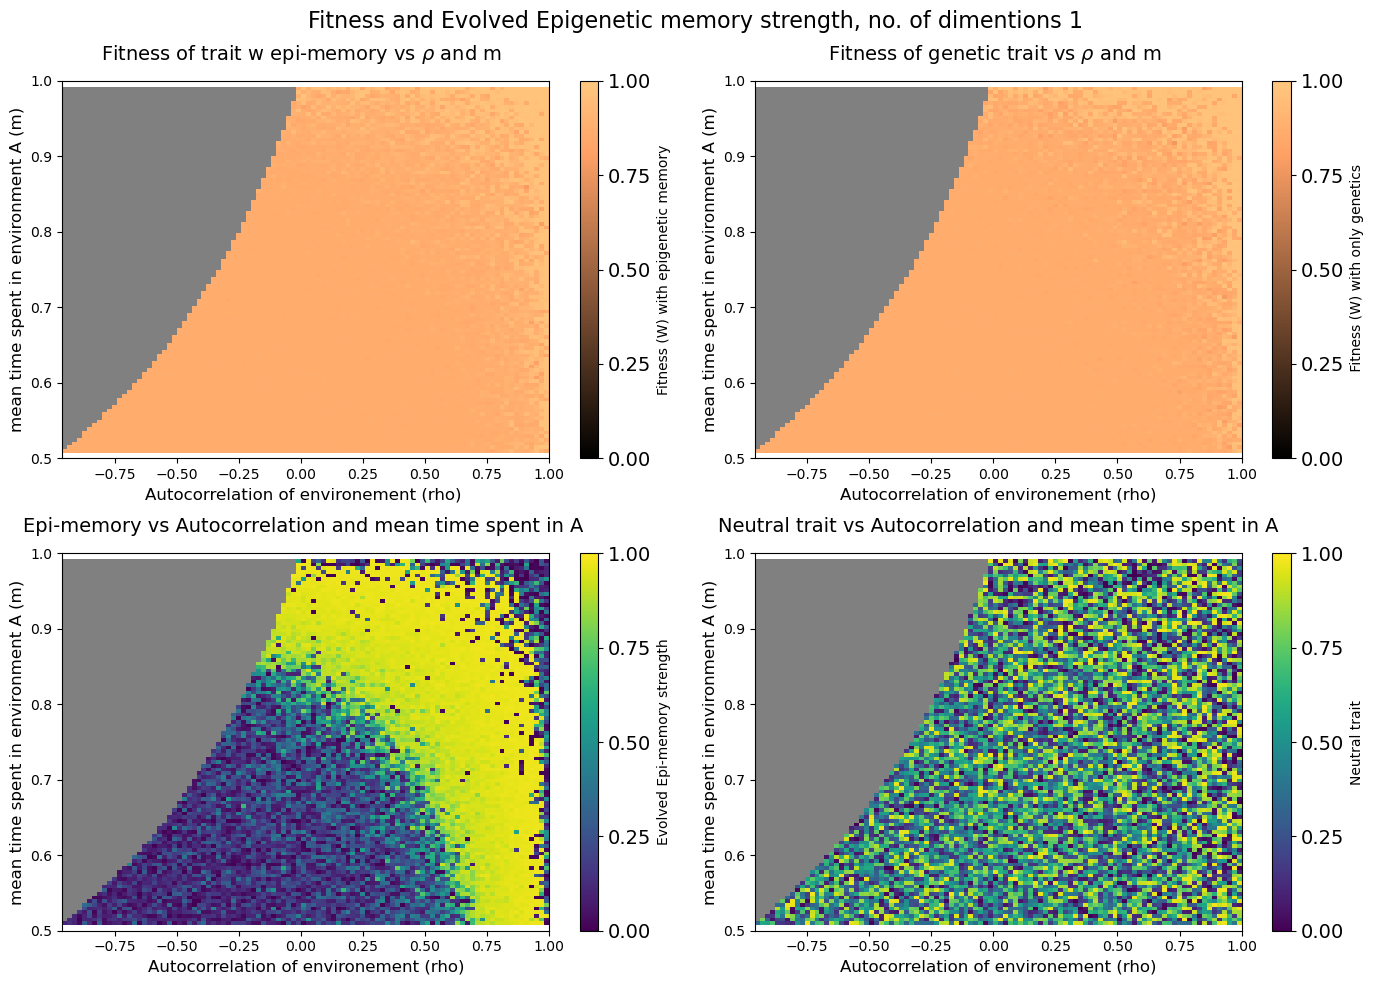

In [ ]:
nof_dims=1

#---------------
#Plot 3 : heatmap of final memory 
#--------------
    
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Fitness and Evolved Transgenerational memory strength, no. of dimentions {nof_dims}", fontsize=16)
fig.subplots_adjust(top=0.90)   # more space for the suptitle
cmap1 = plt.cm.copper.copy()  # copy to modify safely
cmap1.set_bad(color='gray')    # gray for masked values
norm = mcolors.Normalize(vmin=0.0, vmax=1.0)  # consistent color range
    
cmap2 = plt.cm.viridis.copy()  # copy to modify safely
cmap2.set_bad(color='gray')    # gray for masked values
norm = mcolors.Normalize(vmin=0.0, vmax=1.0)  # consistent color range
    

# --- (0,0) fitness ---
pivoted_fitness = df.pivot_table(
        index='m',
        columns='rho',
        values='fitness'
    ).sort_index().sort_index(axis=1)

pcm1 = ax[0,0].pcolormesh(
        pivoted_fitness.columns,
        pivoted_fitness.index,
        pivoted_fitness.values,
        cmap=cmap1,
        norm=norm,
        shading='auto'
    )
cbar1 = fig.colorbar(pcm1, ax=ax[0,0], label='Fitness (W) with Transgenerational memory', 
                        ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
cbar1.ax.tick_params(labelsize=14)

ax[0,0].set_ylabel('mean time spent in environment A (m)', fontsize=12)
ax[0,0].set_ylim(0.5,1)
ax[0,0].set_xlabel('Autocorrelation of environement (rho) ', fontsize=12)
ax[0,0].set_title(rf'Fitness of trait w Transgenerational-memory vs $\rho$ and m  ', fontsize=14,   pad=15   )

    # --- (0,1) genetic fitness ---
pivoted_gen = df_gen.pivot_table(
        index='m',
        columns='rho',
        values='fitness'
    ).sort_index().sort_index(axis=1)

pcm2 = ax[0,1].pcolormesh(
        pivoted_gen.columns,
        pivoted_gen.index,
        pivoted_gen.values,
        cmap=cmap1,
        norm=norm,
        shading='auto'
    )
cbar2 = fig.colorbar(pcm2, ax=ax[0,1], 
                        label=' Fitness (W) with only genetics',
                        ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
cbar2.ax.tick_params(labelsize=14)

ax[0,1].set_ylabel('mean time spent in environment A (m)', fontsize=12)
ax[0,1].set_ylim(0.5,1)
ax[0,1].set_xlabel('Autocorrelation of environement (rho)', fontsize=12)
ax[0,1].set_title( rf'Fitness of genetic trait vs $\rho$ and m  ', fontsize=14,   pad=15   )

    # --- (1,0) epimem ---
pivoted_epi = df.pivot_table(
        index='m',
        columns='rho',
        values='epi_mem_p'
    ).sort_index().sort_index(axis=1)

pcm3 = ax[1,0].pcolormesh(
        pivoted_epi.columns,
        pivoted_epi.index,
        pivoted_epi.values,
        cmap=cmap2,
        norm=norm,
        shading='auto'
    )
cbar3 = fig.colorbar(pcm3, ax=ax[1,0], label=r'Evolved Transgenerational-memory strength',
                        ticks=[0, 0.25, 0.5, 0.75, 1.0])
cbar3.ax.tick_params(labelsize=14)

ax[1,0].set_ylabel('mean time spent in environment A (m)', fontsize=12)/home/usriniva/Epi_kok/impport_packages.ipynb
ax[1,0].set_ylim(0.5,1)
ax[1,0].set_xlabel('Autocorrelation of environement (rho)', fontsize=12)
ax[1,0].set_title('Transgenerational-memory vs Autocorrelation and mean time spent in A ', fontsize=14,   pad=15   )

    # --- (1,1) neutral ---
pivoted_neutral = df.pivot_table(
        index='m',
        columns='rho',
        values='neutral_trait_p'
    ).sort_index().sort_index(axis=1)

pcm4 = ax[1,1].pcolormesh(
        pivoted_neutral.columns,
        pivoted_neutral.index,
        pivoted_neutral.values,
        cmap=cmap2,
        norm=norm,
        shading='auto'
    )
cbar4 = fig.colorbar(pcm4, ax=ax[1,1], label='Neutral trait',
                        ticks=[0.0, 0.25, 0.5, 0.75, 1.0])
cbar4.ax.tick_params(labelsize=14)

ax[1,1].set_ylabel('mean time spent in environment A (m)', fontsize=12)
ax[1,1].set_ylim(0.5,1)
ax[1,1].set_xlabel('Autocorrelation of environement (rho)', fontsize=12)
ax[1,1].set_title('Neutral trait vs Autocorrelation and mean time spent in A', fontsize=14,  pad=15   )
    
    

plt.tight_layout()
plt.show()

#### 3 Dimensions

20 dimensions